In [ ]:
%%writefile sort.cpp

#include <iostream>
#include <omp.h>
#include <vector>
#include <cstdlib>
#include <cstdio>
#include <ctime>

using namespace std;

#define TESTS 6
int N_values[TESTS] = {100, 300, 500, 700, 900, 1000};

// ================= UTILITY =================
void generateArray(vector<int> &arr, int N) {
    for (int i = 0; i < N; i++)
        arr[i] = rand() % 10000;
}

void copyArray(vector<int> &src, vector<int> &dest, int N) {
    for (int i = 0; i < N; i++)
        dest[i] = src[i];
}

// ================= MERGE SORT =================
void merge(vector<int> &arr, int l, int m, int r) {
    vector<int> L(arr.begin() + l, arr.begin() + m + 1);
    vector<int> R(arr.begin() + m + 1, arr.begin() + r + 1);

    int i = 0, j = 0, k = l;

    while (i < L.size() && j < R.size()) {
        if (L[i] <= R[j]) arr[k++] = L[i++];
        else arr[k++] = R[j++];
    }

    while (i < L.size()) arr[k++] = L[i++];
    while (j < R.size()) arr[k++] = R[j++];
}

void sequential_merge(vector<int> &arr, int l, int r) {
    if (l < r) {
        int m = (l + r) / 2;
        sequential_merge(arr, l, m);
        sequential_merge(arr, m + 1, r);
        merge(arr, l, m, r);
    }
}

void parallel_merge(vector<int> &arr, int l, int r, int depth = 0) {
    if (l < r) {
        int m = (l + r) / 2;

        if (depth < 4) {
#pragma omp parallel sections
            {
#pragma omp section
                parallel_merge(arr, l, m, depth + 1);
#pragma omp section
                parallel_merge(arr, m + 1, r, depth + 1);
            }

        }

        else {
            sequential_merge(arr, l, m);
            sequential_merge(arr, m + 1, r);
        }

        merge(arr, l, m, r);
    }
}

// ================= BUBBLE SORT =================
void seq_bubble(vector<int> &arr, int N) {
    for (int i = 0; i < N - 1; i++)
        for (int j = 0; j < N - i - 1; j++)
            if (arr[j] > arr[j + 1])
                swap(arr[j], arr[j + 1]);
}


void par_bubble(vector<int> &arr, int N) {

    for (int phase = 0; phase < N; phase++) {

        // ================= EVEN PHASE =================
        if (phase % 2 == 0) {

            #pragma omp parallel for
            for (int i = 0; i < N - 1; i += 2) {
                if (arr[i] > arr[i + 1]) {
                    swap(arr[i], arr[i + 1]);
                }
            }

        }
        // ================= ODD PHASE =================
        else {

            #pragma omp parallel for
            for (int i = 1; i < N - 1; i += 2) {
                if (arr[i] > arr[i + 1]) {
                    swap(arr[i], arr[i + 1]);
                }
            }
        }
    }
}


// ================= MAIN =================
int main() {

    srand(time(NULL));
    int cores = omp_get_max_threads();

    FILE *merge_f = fopen("merge_output.txt", "w");
    FILE *bubble_f = fopen("bubble_output.txt", "w");

    // ✅ Added COST column
    fprintf(merge_f, "N,SEQ,PAR,SPEEDUP,EFFICIENCY,COST,CORES\n");
    fprintf(bubble_f, "N,SEQ,PAR,SPEEDUP,EFFICIENCY,COST,CORES\n");

    for (int t = 0; t < TESTS; t++) {

        int N = N_values[t];
        vector<int> arr(N), temp(N);

        generateArray(arr, N);

        double seq, par, speed, eff, cost;

        cout << "\n============================\n";
        cout << "N = " << N << endl;

        // ===== MERGE =====
        copyArray(arr, temp, N);
        seq = omp_get_wtime();
        sequential_merge(temp, 0, N - 1);
        seq = omp_get_wtime() - seq;

        copyArray(arr, temp, N);
        par = omp_get_wtime();
        parallel_merge(temp, 0, N - 1);
        par = omp_get_wtime() - par;

        speed = seq / par;
        eff = speed / cores;

        // ✅ COST = Parallel Time × Cores
        cost = par * cores;

        cout << "MERGE  -> "
             << "Seq=" << seq
             << " Par=" << par
             << " Speedup=" << speed
             << " Efficiency=" << eff
             << " Cost=" << cost << endl;

        fprintf(merge_f, "%d,%lf,%lf,%lf,%lf,%lf,%d\n",
                N, seq, par, speed, eff, cost, cores);

        // ===== BUBBLE =====
        copyArray(arr, temp, N);
        seq = omp_get_wtime();
        seq_bubble(temp, N);
        seq = omp_get_wtime() - seq;

        copyArray(arr, temp, N);
        par = omp_get_wtime();
        par_bubble(temp, N);
        par = omp_get_wtime() - par;

        speed = seq / par;
        eff = speed / cores;

        cost = par * cores;

        cout << "BUBBLE -> "
             << "Seq=" << seq
             << " Par=" << par
             << " Speedup=" << speed
             << " Efficiency=" << eff
             << " Cost=" << cost << endl;

        fprintf(bubble_f, "%d,%lf,%lf,%lf,%lf,%lf,%d\n",
                N, seq, par, speed, eff, cost, cores);
    }

    fclose(merge_f);
    fclose(bubble_f);

    cout << "\nResults saved.\n";
    return 0;
}

Overwriting sort.cpp


In [ ]:
# g++ -fopenmp sort.cpp -o sort
# ./sort

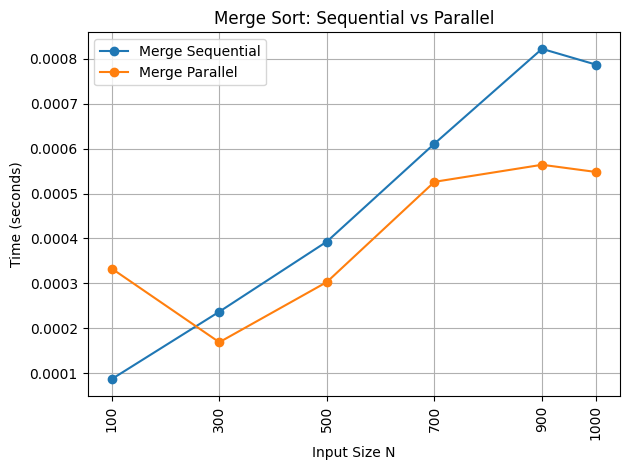

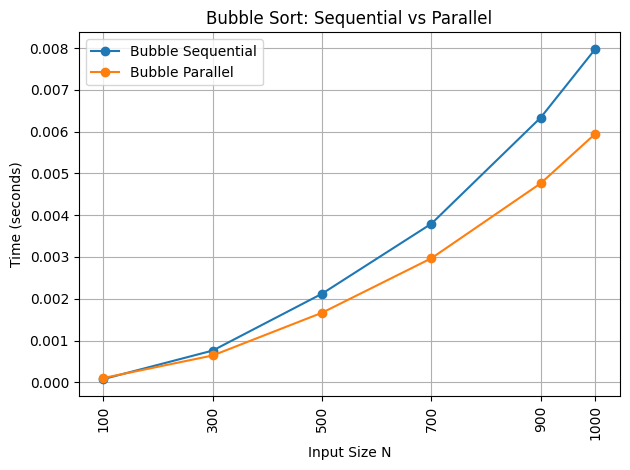

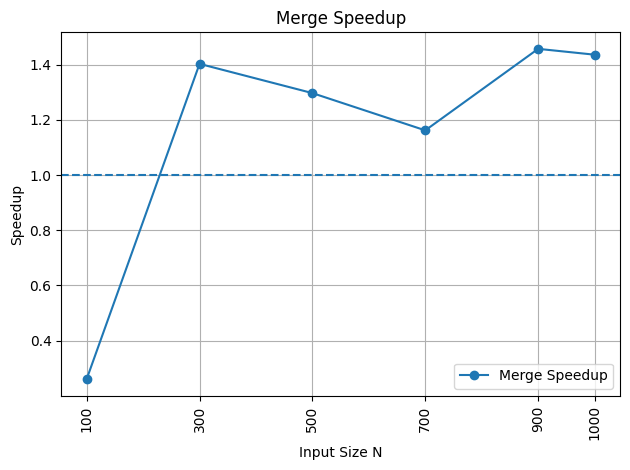

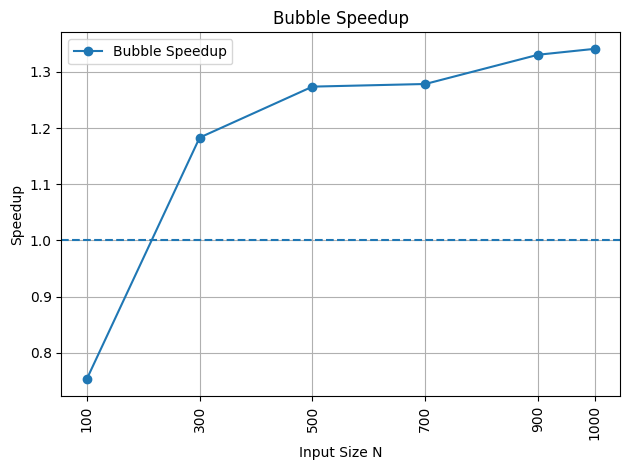

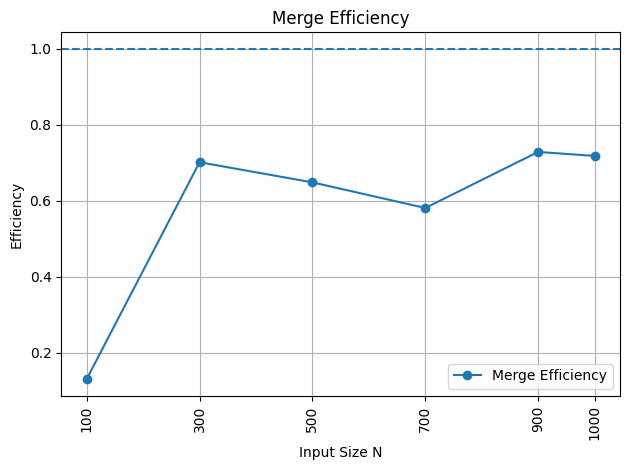

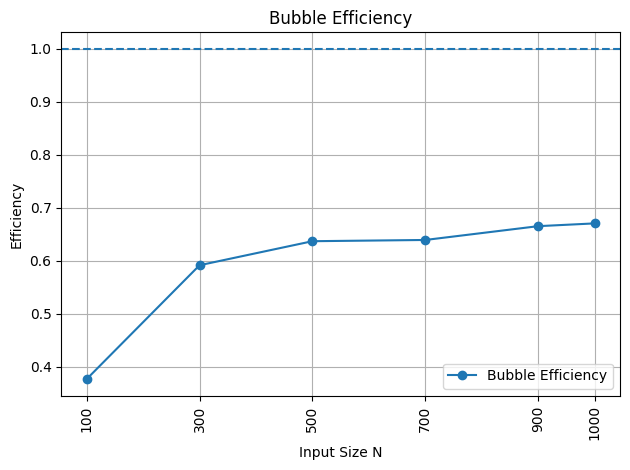

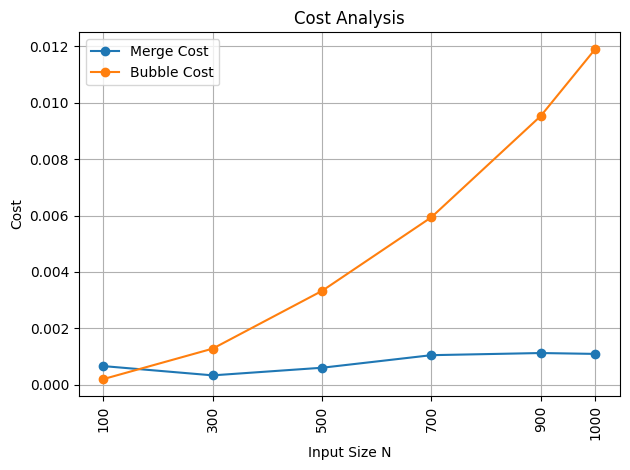

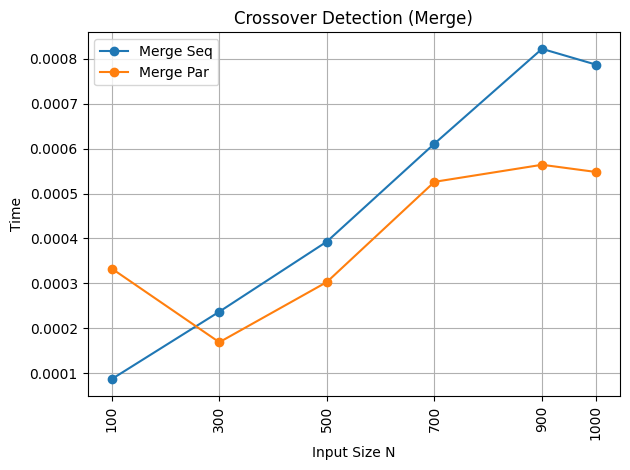

Merge crossover near N = 300


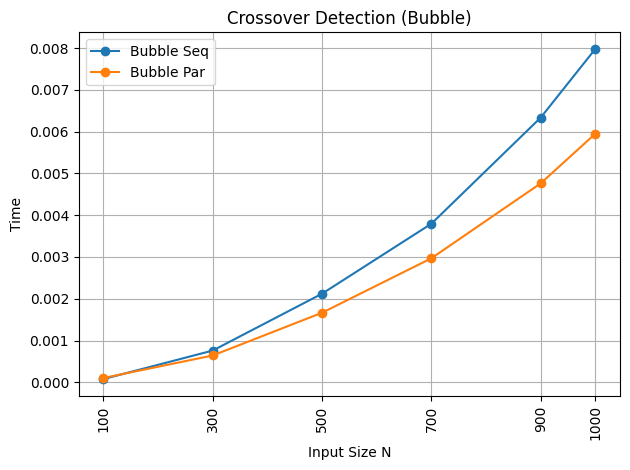

Bubble crossover near N = 100


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= MERGE DATA =================
merge_df = pd.read_csv("merge_output.txt")

N = merge_df["N"].values

merge_seq = merge_df["SEQ"].values
merge_par = merge_df["PAR"].values
merge_speed = merge_df["SPEEDUP"].values
merge_cost = merge_df["COST"].values

CORES = merge_df["CORES"][0]
merge_eff = merge_speed / CORES

# ================= BUBBLE DATA =================
bubble_df = pd.read_csv("bubble_output.txt")

bubble_seq = bubble_df["SEQ"].values
bubble_par = bubble_df["PAR"].values
bubble_speed = bubble_df["SPEEDUP"].values
bubble_cost = bubble_df["COST"].values

bubble_eff = bubble_speed / CORES


# ================= MERGE TIME =================
plt.figure()

plt.plot(N, merge_seq, marker='o', label="Merge Sequential")
plt.plot(N, merge_par, marker='o', label="Merge Parallel")

plt.xlabel("Input Size N")
plt.ylabel("Time (seconds)")
plt.title("Merge Sort: Sequential vs Parallel")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= BUBBLE TIME =================
plt.figure()

plt.plot(N, bubble_seq, marker='o', label="Bubble Sequential")
plt.plot(N, bubble_par, marker='o', label="Bubble Parallel")

plt.xlabel("Input Size N")
plt.ylabel("Time (seconds)")
plt.title("Bubble Sort: Sequential vs Parallel")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= MERGE SPEEDUP =================
plt.figure()

plt.plot(N, merge_speed, marker='o', label="Merge Speedup")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Merge Speedup")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= BUBBLE SPEEDUP =================
plt.figure()

plt.plot(N, bubble_speed, marker='o', label="Bubble Speedup")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Bubble Speedup")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= MERGE EFFICIENCY =================
plt.figure()

plt.plot(N, merge_eff, marker='o', label="Merge Efficiency")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Merge Efficiency")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= BUBBLE EFFICIENCY =================
plt.figure()

plt.plot(N, bubble_eff, marker='o', label="Bubble Efficiency")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Bubble Efficiency")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= COST GRAPH =================
plt.figure()

plt.plot(N, merge_cost, marker='o', label="Merge Cost")
plt.plot(N, bubble_cost, marker='o', label="Bubble Cost")

plt.xlabel("Input Size N")
plt.ylabel("Cost")
plt.title("Cost Analysis")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= CROSSOVER (MERGE) =================
plt.figure()

plt.plot(N, merge_seq, marker='o', label="Merge Seq")
plt.plot(N, merge_par, marker='o', label="Merge Par")

plt.xlabel("Input Size N")
plt.ylabel("Time")
plt.title("Crossover Detection (Merge)")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

idx = np.argmin(np.abs(merge_seq - merge_par))
print("Merge crossover near N =", N[idx])


# ================= CROSSOVER (BUBBLE) =================
plt.figure()

plt.plot(N, bubble_seq, marker='o', label="Bubble Seq")
plt.plot(N, bubble_par, marker='o', label="Bubble Par")

plt.xlabel("Input Size N")
plt.ylabel("Time")
plt.title("Crossover Detection (Bubble)")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

idx = np.argmin(np.abs(bubble_seq - bubble_par))
print("Bubble crossover near N =", N[idx])